# Packages

In [72]:
import GPKoopman as gpk
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, clear_output
import math
import itertools

# Function Definitions

In [73]:
def generate_basis(x, degree):
    """
    Generate a polynomial basis for a 1D state vector x up to a given degree.
    
    Args:
        x (torch.Tensor): A 1D tensor of shape (d,).
        degree (int): Maximum degree of the polynomial basis.
    
    Returns:
        torch.Tensor: A 1D tensor containing the computed polynomial basis.
    """
    # Ensure x is 1D (if it's (d,1) or similar, squeeze it)
    if x.dim() > 1:
        x = x.squeeze()
    
    d = x.shape[0]  # Use the number of elements in the state vector, not the total elements.
    basis = [torch.tensor(1.0, dtype=x.dtype, device=x.device)]  # constant term
    
    for deg in range(1, degree + 1):
        for indices in itertools.combinations_with_replacement(range(d), deg):
            term = torch.prod(x[list(indices)])
            basis.append(term)
    
    return torch.stack(basis)

def generate_basis_batch(X, degree):
    """
    Generate a polynomial basis for each state vector in a batch.
    
    Args:
        X (torch.Tensor): A 2D tensor with shape (state_dim, num_states).
        degree (int): Maximum degree of the polynomial basis.
    
    Returns:
        torch.Tensor: A 2D tensor where each column is the polynomial basis of the corresponding state vector.
    """
    state_dim, num_states = X.shape
    # Compute the size of the basis by generating it once
    single_basis = generate_basis(X[:, 0], degree)
    basis_size = single_basis.numel()
    
    # Pre-allocate tensor for efficiency
    basis_tensor = torch.empty(basis_size, num_states, dtype=X.dtype, device=X.device)
    
    for i in range(num_states):
        basis_tensor[:, i] = generate_basis(X[:, i], degree)
    
    return basis_tensor

# Data Loading

In [74]:
# Allowed system names -
# "Unforced Duffing"
# "Unforced Duffing"_right - domain restricted to right equilibrium point only
# "van der Pol"
# "Simple Pendulum"
# "Lorenz"
# "Lotka Volterra"
# "Piecewise Linear"

system_name = 'Unforced Duffing'
data = torch.load(f"Data/DataAuto_{system_name}.pt", weights_only=True)

SimData = data["trajectories"] # Shape: (num_trajectories, state_dim, num_steps)
ts = data["sample_time"]
num_trajectories = data["num_trajectories"]
N = data["num_steps"]
nTrain = math.floor(num_trajectories * 0.5)
nTest = math.floor(num_trajectories * 0.2)

SimData = SimData.float()
n = SimData.shape[1]

Xall = torch.cat([SimData[j, :, :] for j in range(nTrain)], dim=1)      # Concatenated total matrix
X = torch.cat([SimData[j, :, 0:N] for j in range(nTrain)], dim=1)       # Concatenated Data matrix
Xplus = torch.cat([SimData[j, :, 1:] for j in range(nTrain)], dim=1)    # Time-shifted Data matrix

ICsetTrain = torch.cat([SimData[j, :, 0].view(n,1) for j in range(nTrain)], dim=1)    # Random IC set for training
ICsetTest = torch.cat([SimData[j, :, 0].view(n,1) for j in range(nTrain, nTrain + nTest)], dim=1)  # Random IC set for testing

# Do eDMD

In [75]:
# Example usage:
max_deg = 11
phi_batch = lambda X: generate_basis_batch(X, max_deg)

# Suppose x_current and x_next are PyTorch tensors representing your state
# x_current = torch.tensor([...], dtype=torch.float32)
# x_next = torch.tensor([...], dtype=torch.float32)

# Lift state with generated polynomial basis functions
phi_x = phi_batch(X)
phi_xplus = phi_batch(Xplus)

A_edmd = phi_xplus @ torch.linalg.pinv(phi_x)
C_edmd = X @ torch.linalg.pinv(phi_x)
p = A_edmd.shape[0]

In [76]:
# Evaluation on training set
ZedTrain = torch.empty((nTrain, p, N))    # n+p for state-augmentation
#ZmeanTrain[:, :n, 0] = ICsetTrain.T    # only for state-augmentation

XedTrain = torch.empty((nTrain, n, N))
TrainRMSE_eDMD = torch.empty((nTrain,n))

for j in range(nTrain): # GP Predict for all training trajectories
    ZedTrain[j, :, 0] = phi_batch(ICsetTrain[:, j].view(n,1)).view(p,)        # n+i for state-augmentation
        
    ZedTrain[j, :, :], XedTrain[j, :, :] = gpk.sim_LTI(ZedTrain[j,:,0], A_edmd, C_edmd, num_steps=N, ts=None, x0cv=None)
    TrainRMSE_eDMD[j,:] = torch.sqrt(torch.mean((XedTrain[j,:,:] - SimData[j,:,:N])**2,1))


# Evaluation on test set
ZedTest = torch.empty((nTest, p, N))
#ZmeanTest[:, :n, 0] = ICsetTest.T  # only for state-augmentation

XedTest = torch.empty((nTest, n, N))
TestRMSE_eDMD = torch.empty((nTest,n))

for j in range(nTest): # GP Predict for all training trajectories
    ZedTest[j, :, 0] = phi_batch(ICsetTest[:, j].view(n,1)).view(p,)          # n+i for state-augmentation

    ZedTest[j, :, :], XedTest[j, :, :] = gpk.sim_LTI(ZedTest[j,:,0], A_edmd, C_edmd, num_steps=N, ts=None, x0cv=None)
    TestRMSE_eDMD[j,:] = torch.sqrt(torch.mean((XedTest[j,:,:] - SimData[nTest+j,:,:N])**2,1))

XedTrain, XedTest = XedTrain.detach(), XedTest.detach()
TestRMSE_eDMD, TrainRMSE_eDMD = TestRMSE_eDMD.detach(), TrainRMSE_eDMD.detach()

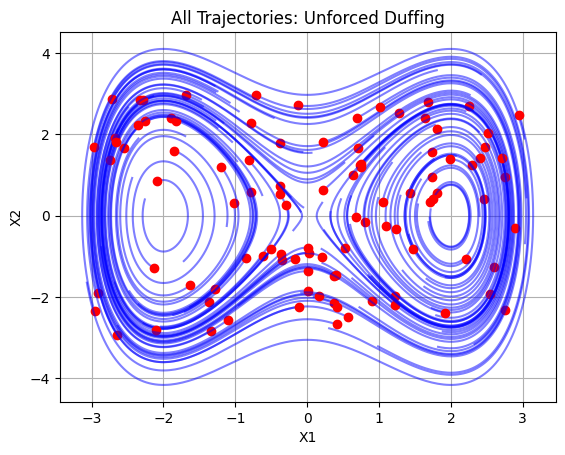

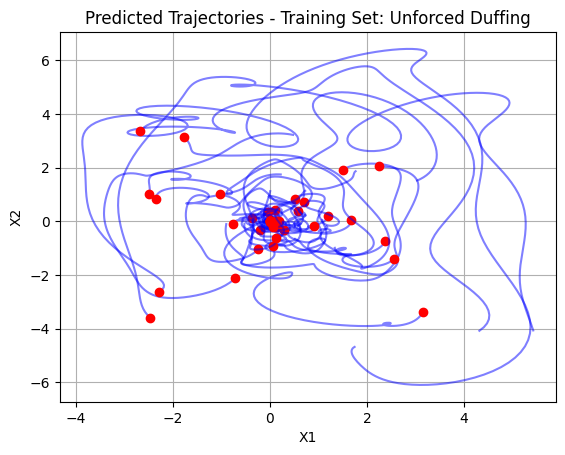

In [77]:
# Phase Diagram from all IC simulation
for j in range(SimData.shape[0]):
    plt.plot(SimData[j,0,:], SimData[j,1,:], alpha=0.5, color='blue')
    plt.plot(SimData[j,0,0], SimData[j,1,0], 'o', color='red')

plt.grid()
plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f'All Trajectories: {system_name}')
plt.show()

# Training Set Predicted Trajectories
for j in range(XedTrain.shape[0]):
    plt.plot(XedTrain[j,0,:], XedTrain[j,1,:], alpha=0.5, color='blue')
    plt.plot(XedTrain[j,0,0], XedTrain[j,1,0], 'o', color='red')

plt.grid()
plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f'Predicted Trajectories - Training Set: {system_name}')
plt.show()